In [64]:
import os
import sys
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("code"))

from protein_from_RNA import *
from reconstruct_simulated_RNA_history import *

In [10]:
%%latex
\begin{align*}
\frac{dU}{dt} &= \alpha - \beta\,U
\qquad
\frac{dS}{dt} &= \beta\,U - \gamma\,S
\end{align*}

<IPython.core.display.Latex object>

In [11]:
%%latex
\begin{align*}
\frac{dU}{dt} &= \alpha - \beta\,U \\
\frac{dS}{dt} &= \beta\,U - \gamma\,S
\end{align*}

<IPython.core.display.Latex object>

Some refs for getting reverse time Markov generator:

https://arxiv.org/abs/2502.19183 (p. 3)

https://www.randomservices.org/random/markov/TimeReversal2.html
 
https://link.springer.com/book/10.1007/978-1-4612-3038-0 (p. 239)

In [180]:
# ==== Transcription rate ====
alpha_mu = 2 # (Corresponds to ~7 mRNAs/hour, per Chronocell paper)
alpha_sd = 1

# === Splicing rate ===
beta_mu = 2 # np.log(splicing_rate) # (Corresponds to ~8.5 minute splicing rate, per Chronocell paper)
beta_sd = 0.5

# === mRNA degradation rate ===
gamma_mu = 0.5 # (Corresponds to ~2.8 hour half-life, per Chronocell paper)
gamma_sd = 0.5

n = 100 # No. cells per lineage
p = 1 # No. genes
topo = np.array([[0, 1, 2, 3]])
tau = (0, 2, 6, 8)

U_max = 10 
S_max = 25

In [181]:
# Simulate data

random_seed = 666 
# np.random.seed(random_seed)

theta = get_RNA_params(topo, p, alpha_mu, alpha_sd, beta_mu, beta_sd, gamma_mu, gamma_sd, random_seed=random_seed)
Y_observed, Y, theta, rd, true_t, true_l = simulate_RNA(topo, tau, theta, n, random_seed=random_seed)

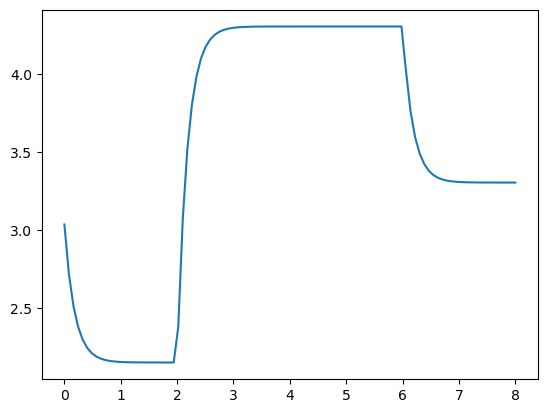

In [182]:
plt.plot(true_t, Y[:, :, 0])

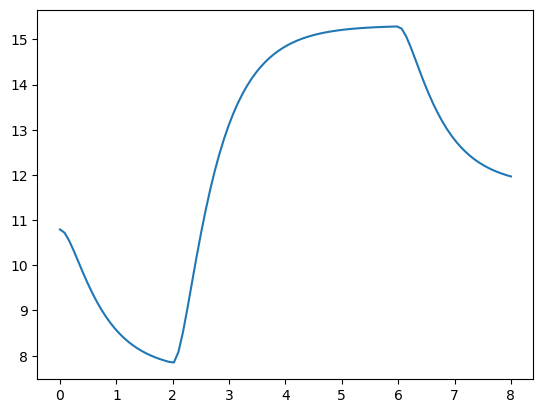

In [68]:
plt.plot(true_t, Y[:, :, 1])

In [183]:
t = true_t
theta_ = theta[0].copy()
a0 = theta_[0] # Starting unspliced RNA abundance 
a = theta_[1:len(topo.flatten())] 
beta = theta_[-2] # Splicing rate
alpha = a * beta # These values are divided by splicing rate; removing this factor now
gamma = theta_[-1] # Degradation rate
state_grid = np.searchsorted(tau, t, side="left") - 1 # Right closed convention τ_j < t_i ≤ τ_{j+1} (per Chronocell model)
state_grid[0] = 0

states, index_for = enumerate_states(U_max, S_max)

# Reverse generator

### Dense implementation

In [7]:
# Prep forward rate matrices

A = []
for i in range(0, len(alpha)):
    rxns = define_reactions(alpha[i], beta, gamma)
    A1 = create_transition_matrix(rxns, U_max, S_max)
    A.append(A1)

In [ ]:
%%latex

\begin{align*}
A &=
\begin{pmatrix}
-\alpha & 0 & \alpha & 0 \\
\gamma & -(\alpha+\gamma) & 0 & \alpha \\
0 & \beta & -\beta & 0 \\
0 & 0 & \gamma & -\gamma
\end{pmatrix}
\end{align*}

In [8]:
# Initialize X_fwd with stationary distribution (steady state at t=0)

alpha0 = a0 * beta
pi = stationary_from_params(alpha0, beta, gamma, states)

In [9]:
states[np.argmax(pi)]

(3, 10)

In [10]:
u_curr = np.round(Y[0, :, 0])[0]
s_curr = np.round(Y[0, :, 1])[0]
u_curr, s_curr

(np.float64(3.0), np.float64(11.0))

In [11]:
# Get forward distribution (needed to calculate backward distribution)

X_fwd = forward_distribution_blocked(A, pi, states, t, tau, state_grid)

In [12]:
gene_idx = 0

Y_gene = Y[:, gene_idx, :]

X_bw = backward_distribution(Y_gene, states, index_for, t, tau, state_grid)

In [13]:
cell_idx = 99
state_idx = np.argmax(X_bw[:, :, cell_idx], axis=0)
# state_idx
[print(states[val], Y[i, gene_idx, 0], Y[i, gene_idx, 1]) for i, val in enumerate(state_idx)]


(2, 10) 3.0345065028600136 10.793420301900941
(2, 10) 2.715033927969497 10.719665419686976
(2, 10) 2.5110515782151586 10.546656404139943
(2, 9) 2.3808094157210524 10.32519521534325
(2, 9) 2.297650157522634 10.085950566016585
(2, 9) 2.244553202652707 9.846945680431148
(2, 9) 2.210650944773828 9.61831437755719
(2, 9) 2.189004447491608 9.405315929238068
(2, 8) 2.1751832192340923 9.21024074478701
(2, 8) 2.1663584034657117 9.033610137704034
(2, 8) 2.1607237831631694 8.874927381215986
(2, 8) 2.157126093785044 8.733144039572995
(2, 8) 2.1548289791319704 8.60694606977274
(2, 8) 2.153362277820442 8.494926227688424
(2, 8) 2.152425793115876 8.395685096769522
(2, 8) 2.151827850238896 8.30788761514469
(2, 8) 2.1514460653764327 8.230292134153672
(2, 8) 2.1512022968045215 8.161762771796372
(2, 8) 2.151046651249933 8.101271834782642
(2, 7) 2.1509472719965976 8.047896547091934
(2, 7) 2.1508838186199837 8.00081271418496
(2, 7) 2.1508433038156505 7.959286933911278
(2, 7) 2.150817435225865 7.9226683231212

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [14]:
# # Visualize marginals for U and S

# X_fwd_U, X_fwd_S = marginal_distribution(X_fwd, U_max, S_max, t, states)

# k=1

# plt.figure()
# plt.bar(np.arange(0, S_max + 1) , X_fwd_S[:, k], width=0.9, align='center')
# plt.xlabel("# spliced molecules")
# plt.ylabel("P(S)")
# plt.title(f"Marginal distribution of S for t = {np.round(t[k], 2)}")
# plt.show()

# plt.figure()
# plt.bar(np.arange(0, U_max + 1) , X_fwd_U[:, k], width=0.9, align='center')
# plt.xlabel("# unspliced molecules")
# plt.ylabel("P(U)")
# plt.title(f"Marginal distribution of U for t = {np.round(t[k], 2)}")
# plt.show()

In [15]:
# # Old code: start t=0 at pi, but it should be pi up UNTIL 0, and anything after uses rates associated with first state

# from scipy.sparse.linalg import expm_multiply

# X_fwd = np.zeros(shape=(len(states), len(t)))
# X_fwd[:, 0] = pi

# for k in range(0, len(t)-1): 
#     t_curr, t_next = t[k], t[k+1]
#     state_curr, state_next = state_grid[k], state_grid[k+1]
#     x_curr = X_fwd[:, k]
        
#     if state_curr == state_next:
#         dt = t_next - t_curr
#         A_k = A[state_curr]
#         x_next = expm_multiply(A_k.T * dt, x_curr) # x_curr @ sp.linalg.expm(A_k * dt) 
        
#     else:   
#         # State switch happens in current interval
#         t_s = tau[state_next]

#         # Split backward march into 2 steps
#         dt1 = t_s - t_curr # left interval: [t_k, state_switch_time)
#         A_k1 = A[state_curr]
#         x_mid = expm_multiply(A_k1.T * dt1, x_curr) # x_curr @ sp.linalg.expm(A_k1 * dt1)
    
#         dt2 = t_next - t_s # right interval: [state_switch_time, t_{k+1})
#         A_k2 = A[state_next]
#         x_next = expm_multiply(A_k2.T * dt2, x_mid)  # x_mid @ sp.linalg.expm(A_k2 * dt2) 
    
#     X_fwd[:, k+1] = x_next
    
#     print("Jump forwards from t =", np.round(t_curr, 3), "to t =", np.round(t_next, 3), ":")
#     print("Highest probability state (# unspliced, spliced):", states[np.argmax(x_curr)])
#     idx = np.searchsorted(t, t_next)
#     print("Simulated (# unspliced, spliced):", np.round(Y[idx, :, 0], 2), np.round(Y[idx, :, 1], 2))
#     print("Sum X(t_k) =", np.sum(x_curr))
#     print("-------") 

### Sparse implementation

In [16]:
# Prep forward rate matrices

A = []
for i in range(0, len(alpha)):
    rxns = define_reactions(alpha[i], beta, gamma)
    A1 = create_transition_matrix_sparse(rxns, states, index_for, U_max, S_max)
    A.append(A1)

In [17]:
# Initialize X_fwd with stationary distribution (steady state at t=0)

alpha0 = a0 * beta
pi = stationary_from_params(alpha0, beta, gamma, states)
X_fwd = forward_distribution_blocked(A, pi, states, t, tau, state_grid)

In [18]:
state_idx = np.argmax(X_fwd, axis=0)
[print(states[val], Y[i, :, 0], Y[i, :, 1]) for i, val in enumerate(state_idx)]

(2, 10) [3.0345065] [10.7934203]
(2, 10) [2.71503393] [10.71966542]
(2, 10) [2.51105158] [10.5466564]
(2, 10) [2.38080942] [10.32519522]
(2, 9) [2.29765016] [10.08595057]
(2, 9) [2.2445532] [9.84694568]
(2, 9) [2.21065094] [9.61831438]
(2, 9) [2.18900445] [9.40531593]
(2, 9) [2.17518322] [9.21024074]
(2, 8) [2.1663584] [9.03361014]
(2, 8) [2.16072378] [8.87492738]
(2, 8) [2.15712609] [8.73314404]
(2, 8) [2.15482898] [8.60694607]
(2, 8) [2.15336228] [8.49492623]
(2, 8) [2.15242579] [8.3956851]
(2, 8) [2.15182785] [8.30788762]
(2, 8) [2.15144607] [8.23029213]
(2, 8) [2.1512023] [8.16176277]
(2, 8) [2.15104665] [8.10127183]
(2, 8) [2.15094727] [8.04789655]
(2, 7) [2.15088382] [8.00081271]
(2, 7) [2.1508433] [7.95928693]
(2, 7) [2.15081744] [7.92266832]
(2, 7) [2.15080092] [7.89038033]
(2, 7) [2.15079037] [7.86191292]
(2, 7) [2.37913888] [7.84972352]
(3, 8) [3.07464536] [8.08288801]
(3, 8) [3.51872431] [8.5235305]
(3, 9) [3.80226749] [9.06207223]
(3, 9) [3.98330902] [9.63264464]
(4, 10) [4

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [19]:
gene_idx = 0

Y_gene = Y[:, gene_idx, :]

X_bw = backward_distribution_sparse_to_dense(Y_gene, states, index_for, t, tau, state_grid)

In [20]:
cell_idx = 99
state_idx = np.argmax(X_bw[:, :, cell_idx], axis=0)
# state_idx
[print(states[val], Y[i, gene_idx, 0], Y[i, gene_idx, 1]) for i, val in enumerate(state_idx)]


(2, 10) 3.0345065028600136 10.793420301900941
(2, 10) 2.715033927969497 10.719665419686976
(2, 10) 2.5110515782151586 10.546656404139943
(2, 9) 2.3808094157210524 10.32519521534325
(2, 9) 2.297650157522634 10.085950566016585
(2, 9) 2.244553202652707 9.846945680431148
(2, 9) 2.210650944773828 9.61831437755719
(2, 9) 2.189004447491608 9.405315929238068
(2, 8) 2.1751832192340923 9.21024074478701
(2, 8) 2.1663584034657117 9.033610137704034
(2, 8) 2.1607237831631694 8.874927381215986
(2, 8) 2.157126093785044 8.733144039572995
(2, 8) 2.1548289791319704 8.60694606977274
(2, 8) 2.153362277820442 8.494926227688424
(2, 8) 2.152425793115876 8.395685096769522
(2, 8) 2.151827850238896 8.30788761514469
(2, 8) 2.1514460653764327 8.230292134153672
(2, 8) 2.1512022968045215 8.161762771796372
(2, 8) 2.151046651249933 8.101271834782642
(2, 7) 2.1509472719965976 8.047896547091934
(2, 7) 2.1508838186199837 8.00081271418496
(2, 7) 2.1508433038156505 7.959286933911278
(2, 7) 2.150817435225865 7.9226683231212

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

### Misc

In [ ]:
X_bw_U, X_bw_S = marginal_distribution(X_bw, U_max, S_max, t, states)

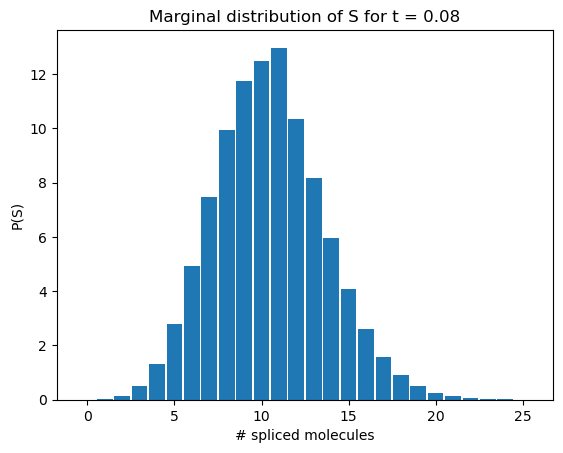

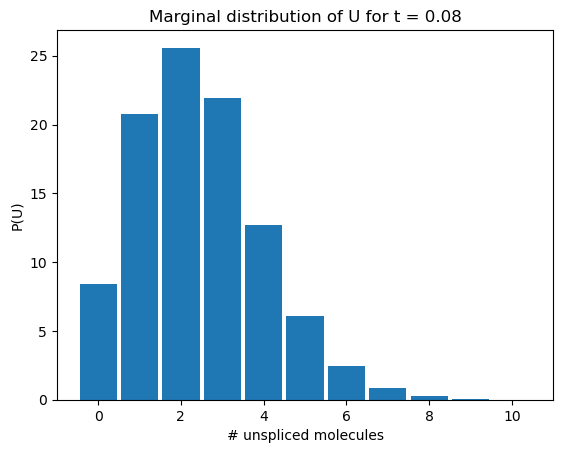

In [22]:
k=1

plt.figure()
plt.bar(np.arange(0, S_max + 1) , X_bw_S[:, k], width=0.9, align='center')
plt.xlabel("# spliced molecules")
plt.ylabel("P(S)")
plt.title(f"Marginal distribution of S for t = {np.round(t[k], 2)}")
plt.show()

plt.figure()
plt.bar(np.arange(0, U_max + 1) , X_bw_U[:, k], width=0.9, align='center')
plt.xlabel("# unspliced molecules")
plt.ylabel("P(U)")
plt.title(f"Marginal distribution of U for t = {np.round(t[k], 2)}")
plt.show()

# Taking inverse to go backwards (old approach)

In [23]:
# Prep forward rate matrices

A = []
for i in range(0, len(alpha)):
    rxns = define_reactions(alpha[i], beta, gamma)
    A1 = create_transition_matrix(rxns, U_max, S_max)
    A.append(A1)

In [24]:
# For each time step, calculate previous state using current state

# Start with observed counts:
u_curr = np.round(Y[-1, :, 0])[0]
s_curr = np.round(Y[-1, :, 1])[0]
x_curr = np.zeros(shape=(A[0].shape[0],), dtype="float")
x_curr[index_for[(u_curr, s_curr)]] = 1.0

print("Start backward process with (# unspliced, spliced):", u_curr, s_curr)
print("Simulated (# unspliced, spliced):", np.round(Y[-1, :, 0], 3), np.round(Y[-1, :, 1], 3))
print("-------")

for k in reversed(range(1, len(t))):
    t_prev, t_curr = t[k-1], t[k]
    # print("t_prev, t_curr:", t_prev, t_curr)
    state_prev, state_curr = state_grid[k-1], state_grid[k]
    # print("state_prev, state_curr:", state_prev, state_curr)

    if state_prev == state_curr:
        dt = t_curr - t_prev
        A_k = A[state_curr]
        x_prev = x_curr @ np.linalg.inv(sp.linalg.expm(A_k * dt)) 
        
    else:
        # State switch happens in current interval
        tau_c = tau[state_curr]
        
        print("State switch at k =", k)
        # print("tau_c:", tau_c)
        # print("t_curr:", t_curr)
        # print("t_prev:", t_prev)
        
        # Split backward march into 2 steps
        # interval 2: (state_switch_time, t_k]
        dt2 = t_curr - tau_c
        A_k2 = A[state_curr]
        x_mid = x_curr @ np.linalg.inv(sp.linalg.expm(A_k2 * dt2)) 
        
        # interval 1: (t_k-1, state_switch_time]
        dt1 = tau_c - t_prev

        A_k1 = A[state_prev]
        x_prev = x_mid @ np.linalg.inv(sp.linalg.expm(A_k1 * dt1)) 
    
    x_curr = x_prev
    
    print("Jump backwards from t =", np.round(t_curr, 3), "to t =", np.round(t_prev, 3), ":")
    print("Highest probability state (# unspliced, spliced):", states[np.argmax(x_curr)])
    idx = np.searchsorted(t, t_prev)
    print("Simulated (# unspliced, spliced):", np.round(Y[idx, :, 0], 2), np.round(Y[idx, :, 1], 2))
    print("Sum X(t_k) =", np.sum(x_curr))
    print("-------")
    

Start backward process with (# unspliced, spliced): 3.0 12.0
Simulated (# unspliced, spliced): [3.303] [11.966]
-------
Jump backwards from t = 8.0 to t = 7.919 :
Highest probability state (# unspliced, spliced): (3, 14)
Simulated (# unspliced, spliced): [3.3] [12.]
Sum X(t_k) = 0.999999999946418
-------
Jump backwards from t = 7.919 to t = 7.838 :
Highest probability state (# unspliced, spliced): (6, 14)
Simulated (# unspliced, spliced): [3.3] [12.03]
Sum X(t_k) = 1.0000000187865226
-------
Jump backwards from t = 7.838 to t = 7.758 :
Highest probability state (# unspliced, spliced): (7, 15)
Simulated (# unspliced, spliced): [3.3] [12.07]
Sum X(t_k) = 1.000007838010788
-------
Jump backwards from t = 7.758 to t = 7.677 :
Highest probability state (# unspliced, spliced): (7, 19)
Simulated (# unspliced, spliced): [3.3] [12.11]
Sum X(t_k) = 0.76708984375
-------
Jump backwards from t = 7.677 to t = 7.596 :
Highest probability state (# unspliced, spliced): (7, 23)
Simulated (# unspliced, 

/tmp/ipykernel_2120980/3277274062.py:22: RuntimeWarning: overflow encountered in matmul
  x_prev = x_curr @ np.linalg.inv(sp.linalg.expm(A_k * dt))
/tmp/ipykernel_2120980/3277274062.py:22: RuntimeWarning: invalid value encountered in matmul
  x_prev = x_curr @ np.linalg.inv(sp.linalg.expm(A_k * dt))
/mnt/lareaulab/reliscu/anaconda3/envs/chronocell/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Jump backwards from t = 2.424 to t = 2.343 :
Highest probability state (# unspliced, spliced): (0, 0)
Simulated (# unspliced, spliced): [3.98] [9.63]
Sum X(t_k) = nan
-------
Jump backwards from t = 2.343 to t = 2.263 :
Highest probability state (# unspliced, spliced): (0, 0)
Simulated (# unspliced, spliced): [3.8] [9.06]
Sum X(t_k) = nan
-------
Jump backwards from t = 2.263 to t = 2.182 :
Highest probability state (# unspliced, spliced): (0, 0)
Simulated (# unspliced, spliced): [3.52] [8.52]
Sum X(t_k) = nan
-------
Jump backwards from t = 2.182 to t = 2.101 :
Highest probability state (# unspliced, spliced): (0, 0)
Simulated (# unspliced, spliced): [3.07] [8.08]
Sum X(t_k) = nan
-------
Jump backwards from t = 2.101 to t = 2.02 :
Highest probability state (# unspliced, spliced): (0, 0)
Simulated (# unspliced, spliced): [2.38] [7.85]
Sum X(t_k) = nan
-------
State switch at k = 25
Jump backwards from t = 2.02 to t = 1.939 :
Highest probability state (# unspliced, spliced): (0, 0)
Sim

In [25]:
# Start with observed counts:
u_curr = np.round(Y[0, :, 0])[0]
s_curr = np.round(Y[0, :, 1])[0]
x_curr = np.zeros(shape=(A[0].shape[0],), dtype="float")
x_curr[index_for[(u_curr, s_curr)]] = 1.0

print("Start forward process with (# unspliced, spliced):", u_curr, s_curr)
print("Simulated (# unspliced, spliced):", np.round(Y[0, :, 0], 3), np.round(Y[0, :, 1], 3))
print("-------")

for k in range(0, len(t)-1): 
    t_curr, t_next = t[k], t[k + 1]
    state_curr, state_next = state_grid[k], state_grid[k+1]
    # x_curr = X_fwd[:, k]
    
    if state_curr == state_next:
        dt = t_next - t_curr
        A_k = A[state_curr]
        x_next = x_curr @ sp.linalg.expm(A_k * dt) 
        
    else:   
        # State switch happens in current interval
        t_s = tau[state_next]

        # Split backward march into 2 steps
        dt1 = t_s - t_curr # left interval: [t_k, state_switch_time)
        A_k1 = A[state_curr]
        x_mid = x_curr @ sp.linalg.expm(A_k1 * dt1)

        dt2 = t_next - t_s # right interval: [state_switch_time, t_{k+1})
        A_k2 = A[state_next]
        x_next = x_mid @ sp.linalg.expm(A_k2 * dt2) 
    
    x_curr = x_next
    
    print("Jump fowards from t =", np.round(t_curr, 3), "to t =", np.round(t_next, 3), ":")
    print("Highest probability state (# unspliced, spliced):", states[np.argmax(x_curr)])
    idx = np.searchsorted(t, t_next)
    print("Simulated (# unspliced, spliced):", np.round(Y[idx, :, 0], 2), np.round(Y[idx, :, 1], 2))
    print("Sum X(t_k) =", np.sum(x_curr))
    print("-------")
    
    # X_fwd[:, k+1] = x_next

Start forward process with (# unspliced, spliced): 3.0 11.0
Simulated (# unspliced, spliced): [3.035] [10.793]
-------
Jump fowards from t = 0.0 to t = 0.081 :
Highest probability state (# unspliced, spliced): (3, 11)
Simulated (# unspliced, spliced): [2.72] [10.72]
Sum X(t_k) = 0.9999999999999994
-------
Jump fowards from t = 0.081 to t = 0.162 :
Highest probability state (# unspliced, spliced): (2, 11)
Simulated (# unspliced, spliced): [2.51] [10.55]
Sum X(t_k) = 0.9999999999999992
-------
Jump fowards from t = 0.162 to t = 0.242 :
Highest probability state (# unspliced, spliced): (2, 10)
Simulated (# unspliced, spliced): [2.38] [10.33]
Sum X(t_k) = 0.9999999999999988
-------
Jump fowards from t = 0.242 to t = 0.323 :
Highest probability state (# unspliced, spliced): (2, 10)
Simulated (# unspliced, spliced): [2.3] [10.09]
Sum X(t_k) = 0.9999999999999987
-------
Jump fowards from t = 0.323 to t = 0.404 :
Highest probability state (# unspliced, spliced): (2, 10)
Simulated (# unspliced,

# Euler's method

In [26]:
import numpy as np

In [27]:
W = np.array([[-beta, 0], [beta, -gamma]])

b = []
for i in range(topo.shape[1]-1):
    b.append(np.array([alpha[i], 0]))

In [44]:
gene_idx = 0

In [ ]:
# Euler forward

X_fwd = np.zeros(shape=(Y.shape[0], 2), dtype="float")
X_fwd[0, :] = Y[0, :, :]

for k in range(len(t)-1):
    t_curr, t_next = t[k], t[k+1]
    state_curr, state_next = state_grid[k], state_grid[k+1]
    X_curr = X_fwd[k, :]
    
    if state_curr == state_next:
        dt = t_next - t_curr
        X_next = X_curr + dt * ((W @ X_curr) + b[state_curr])

    X_fwd[k+1, :] = np.squeeze(X_next)

In [201]:
X_curr = Y[99, 0, :].copy()
X_bw = np.zeros(shape=(len(t), 2), dtype=float)

# Start backwards trajectory at cell's inferred position in time
t_obs = np.arange(Y.shape[0])

for k in reversed(range(1, len(t))):
    t_prev, t_curr = t[k-1], t[k]
    state_prev, state_curr = state_grid[k-1], state_grid[k]

    # Only calculate backwards trajectory for cells at t = t[k] or later
    mask = t_obs >= k
    X_curr_block = X_curr

    if state_prev == state_curr:
        dt = t_curr - t_prev
        X_prev = X_curr_block - dt * (X_curr_block @ W.T + b[state_curr])
    
    else:
        # State switch happens in current interval           
        t_s = tau[state_curr]
        
        # Split backward march into 2 steps
        dt2 = t_curr - t_s # right interval: (state_switch_time, t_k]
        X_mid = X_curr_block - dt2 * (X_curr_block @ W.T + b[state_curr])

        dt1 = t_s - t_prev # left interval: (t_{k-1}, state_switch_time]
        X_prev = X_mid - dt1 * (X_mid @ W.T + b[state_prev])

    X_bw[k, :] = X_curr_block
    X_bw[k-1, :] = X_prev
    X_curr = X_prev
    
    print("k", k)
    print("X_bw", X_bw[k-1, :])
    print("Y", Y[k-1, :, :])
    print("----")

k 99
X_bw [ 3.30327829 11.99386505]
Y [[ 3.30328006 11.99566506]]
----
k 98
X_bw [ 3.30328807 12.02469822]
Y [[ 3.3032934 12.0287654]]
----
k 97
X_bw [ 3.30330224 12.05941606]
Y [[ 3.30331431 12.06630747]]
----
k 96
X_bw [ 3.30332277 12.09850656]
Y [[ 3.30334705 12.10888383]]
----
k 95
X_bw [ 3.30335251 12.14251841]
Y [[ 3.30339833 12.15716414]]
----
k 94
X_bw [ 3.30339559 12.19206821]
Y [[ 3.30347863 12.21190406]]
----
k 93
X_bw [ 3.303458  12.2478485]
Y [[ 3.30360441 12.27395454]]
----
k 92
X_bw [ 3.30354842 12.31063647]
Y [[ 3.3038014  12.34427104]]
----
k 91
X_bw [ 3.30367939 12.38130344]
Y [[ 3.30410992 12.42392199]]
----
k 90
X_bw [ 3.30386912 12.46082502]
Y [[ 3.30459312 12.51409527]]
----
k 89
X_bw [ 3.30414397 12.55029168]
Y [[ 3.3053499 12.6161005]]
----
k 88
X_bw [ 3.30454213 12.65091963]
Y [[ 3.30653514 12.73136395]]
----
k 87
X_bw [ 3.30511892 12.76406135]
Y [[ 3.30839145 12.86141062]]
----
k 86
X_bw [ 3.30595449 12.89121508]
Y [[ 3.31129875 13.0078248 ]]
----
k 85
X_bw [ 

In [195]:
X_bw

array([[-7.93127741e+11,  1.10331952e+12],
       [-5.47498934e+11,  7.61625432e+11],
       [-3.77940485e+11,  5.25752776e+11],
       [-2.60893677e+11,  3.62929033e+11],
       [-1.80095844e+11,  2.50531217e+11],
       [-1.24320809e+11,  1.72942600e+11],
       [-8.58191022e+10,  1.19382899e+11],
       [-5.92412352e+10,  8.24104441e+10],
       [-4.08944378e+10,  5.68882257e+10],
       [-2.82295776e+10,  3.92701465e+10],
       [-1.94869790e+10,  2.71083231e+10],
       [-1.34519318e+10,  1.87129727e+10],
       [-9.28591692e+09,  1.29176321e+10],
       [-6.41010187e+09,  8.91708769e+09],
       [-4.42491639e+09,  6.15549750e+09],
       [-3.05453571e+09,  4.24916187e+09],
       [-2.10855699e+09,  2.93321156e+09],
       [-1.45554448e+09,  2.02480634e+09],
       [-1.00476759e+09,  1.39773096e+09],
       [-6.93594686e+08,  9.64858587e+08],
       [-4.78790907e+08,  6.66045245e+08],
       [-3.30511086e+08,  4.59773332e+08],
       [-2.28152992e+08,  3.17383099e+08],
       [-1.

In [ ]:
# X_curr = Y[:, 0, :].copy()
# X_bw = np.zeros(shape=(len(t), Y.shape[0], 2), dtype=float)

# # Start backwards trajectory at cell's inferred position in time
# t_obs = np.arange(Y.shape[0])

# # for k in reversed(range(1, len(t))):

# for k in reversed(range(80, len(t))):
#     t_prev, t_curr = t[k-1], t[k]
#     state_prev, state_curr = state_grid[k-1], state_grid[k]

#     # Only calculate backwards trajectory for cells at t = t[k] or later
#     mask = t_obs >= k
#     X_curr_block = X_curr[mask, :]

#     # if state_prev == state_curr:
#     dt = t_curr - t_prev
#     X_prev = X_curr_block - dt * (X_curr_block @ W.T + b[state_curr])
#     # else:
#     #     # State switch happens in current interval           
#     #     t_s = tau[state_curr]
        
#     #     # Split backward march into 2 steps
#     #     dt2 = t_curr - t_s # right interval: (state_switch_time, t_k]
#     #     X_mid = X_curr_block - dt2 * (X_curr_block @ W.T + b[state_curr])

#     #     dt1 = t_s - t_prev # left interval: (t_{k-1}, state_switch_time]
#     #     X_prev = X_mid - dt1 * (X_mid @ W.T + b[state_prev])

    
#     X_bw[k, mask, :] = X_curr_block
#     X_bw[k-1, mask, :] = X_prev
#     X_curr[mask, :] = X_prev
    
#     print("k", k)
#     print(X_bw[k, mask, :])
#     print("-----")

k 99
[[ 3.30327153 11.96648264]]
-----
k 98
[[ 3.30328006 11.99566506]
 [ 3.30327829 11.99386505]]
-----
k 97
[[ 3.3032934  12.0287654 ]
 [ 3.30329063 12.02672448]
 [ 3.30328807 12.02469822]]
-----
k 96
[[ 3.30331431 12.06630747]
 [ 3.30330997 12.06399384]
 [ 3.30330596 12.06169673]
 [ 3.30330224 12.05941606]]
-----
k 95
[[ 3.30334705 12.10888383]
 [ 3.30334025 12.10626178]
 [ 3.30333397 12.10365828]
 [ 3.30332815 12.10107324]
 [ 3.30332277 12.09850656]]
-----
k 94
[[ 3.30339833 12.15716414]
 [ 3.30338768 12.15419369]
 [ 3.30337783 12.15124397]
 [ 3.30336873 12.14831491]
 [ 3.3033603  12.14540641]
 [ 3.30335251 12.14251841]]
-----
k 93
[[ 3.30347863 12.21190406]
 [ 3.30346196 12.20854068]
 [ 3.30344654 12.20520034]
 [ 3.30343228 12.20188299]
 [ 3.30341908 12.19858856]
 [ 3.30340688 12.195317  ]
 [ 3.30339559 12.19206821]]
-----
k 92
[[ 3.30360441 12.27395454]
 [ 3.3035783  12.27014903]
 [ 3.30355415 12.26636891]
 [ 3.30353181 12.26261416]
 [ 3.30351115 12.25888478]
 [ 3.30349203 12.255

In [159]:
X_bw[:, 99, :]

array([[-6.85000587e+11,  9.52903898e+11],
       [-4.72858370e+11,  6.57792990e+11],
       [-3.26415835e+11,  4.54076867e+11],
       [-2.25326026e+11,  3.13450895e+11],
       [-1.55543367e+11,  2.16376281e+11],
       [-1.07372146e+11,  1.49365325e+11],
       [-7.41193787e+10,  1.03107421e+11],
       [-5.11648739e+10,  7.11754232e+10],
       [-3.53192966e+10,  4.91326504e+10],
       [-2.43810376e+10,  3.39164451e+10],
       [-1.68303180e+10,  2.34126438e+10],
       [-1.16180291e+10,  1.61618320e+10],
       [-8.01996728e+09,  1.11565706e+10],
       [-5.53621228e+09,  7.70142061e+09],
       [-3.82166726e+09,  5.31631818e+09],
       [-2.63811067e+09,  3.66987341e+09],
       [-1.82109729e+09,  2.53332667e+09],
       [-1.25711001e+09,  1.74876439e+09],
       [-8.67787565e+08,  1.20717824e+09],
       [-5.99036879e+08,  8.33319378e+08],
       [-4.13517313e+08,  5.75243275e+08],
       [-2.85452489e+08,  3.97092423e+08],
       [-1.97048880e+08,  2.74114257e+08],
       [-1.

In [ ]:

# for k in reversed(range(1, len(t))):
#     t_prev, t_curr = t[k-1], t[k]
#     state_prev, state_curr = state_grid[k-1], state_grid[k]
    
#     # Only calculate backwards trajectory for cells at t = t[k] or later
#     mask = t_obs >= k
#     X_curr_block = X_curr[mask, :]

#     if state_prev == state_curr:
#         dt = t_curr - t_prev
#         X_prev = X_curr_block - dt * (X_curr_block @ W.T + b[state_curr])
#     else:
#         # State switch happens in current interval           
#         t_s = tau[state_curr]
        
#         # Split backward march into 2 steps
#         dt2 = t_curr - t_s # right interval: (state_switch_time, t_k]
#         X_mid = X_curr_block - dt2 * (X_curr_block @ W.T + b[state_curr])

#         dt1 = t_s - t_prev # left interval: (t_{k-1}, state_switch_time]
#         X_prev = X_mid - dt1 * (X_mid @ W.T + b[state_prev])
    
#     X_bw[k, mask, :] = X_curr_block
#     X_bw[k-1, mask, :] = X_prev
#     X_curr[mask, :] = X_prev

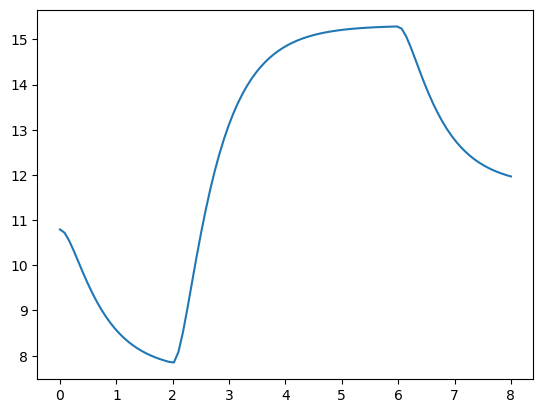

In [75]:
plt.plot(t, Y[:, :, 1])

In [73]:
X_bw.shape

(100, 100, 2)

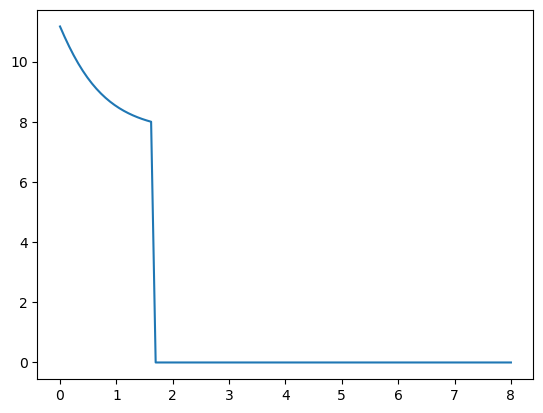

In [78]:
plt.plot(t, X_bw[:, 20, 1])

In [ ]:
k = 0
lambdas_t = Vector_lambda_groudtruth[k] # NS_lambdas[k]
W @ lambdas_t.T + np.array([alpha_per_t[k], 0])

array([-4.9064024e+00,  2.1111404e-10])

In [184]:
X_fwd = np.zeros(shape=(Y.shape[0], 2), dtype="float") # np.zeros(shape=(Y.shape[1], len(t)), dtype="float")
X_fwd[0, :] = np.array([Y[0, :, 0], Y[0, :, 1]]).T
X_fwd[0, :]

t_curr, t_next = t[k], t[k+1]
state_curr, state_next = state_grid[k], state_grid[k+1]
X_curr = X_fwd[0, :]
((W @ X_curr) + b[state_curr])

array([1.49207161e+00, 2.11114040e-10])

In [185]:
X_curr + dt * ((W @ X_curr) + b[state_curr])

array([ 3.15507795, 10.7934203 ])

In [ ]:
state_grid = np.searchsorted(tau, t, side="left") - 1
state_grid[0] = 0 
alpha_per_t = alpha[state_grid]

Vector_lambda_groudtruth = np.concatenate((Y[:, :, 0], Y[:, :, 1]), axis=1) # T -by- 2
Vector_lambda_groudtruth[1, :]

dt_list = np.diff(t) # (T-1) dt
# W = np.array([[-beta, 0], [beta, -gamma]])

# NS_lambdas = np.zeros_like(Vector_lambda_groudtruth) # place holder
# # initial lambdas at t=0 to start numberical approximation of the ODEs
# NS_lambdas[0] = Vector_lambda_groudtruth[0] # [1]

# for k in range(len(dt_list)):
#   lambdas_t = NS_lambdas[k]
#   lambda_tp1 = lambdas_t + dt_list[k] * (W @ lambdas_t.T + np.array([alpha_per_t[k], 0]) )
#   NS_lambdas[k+1] = lambda_tp1

Backward_lambdas = np.zeros_like(Vector_lambda_groudtruth) # place holder
# initial lambdas at t=0 to start numberical approximation of the ODEs
Backward_lambdas[-1] = Vector_lambda_groudtruth[-1]

for k in range(len(dt_list), 1, -1):
  lambdas_t = NS_lambdas[k]
  lambda_tm1 = lambdas_t - dt_list[k-1] * (W @ lambdas_t.T + np.array([alpha_per_t[k], 0]) )
  Backward_lambdas[k-1] = lambda_tm1

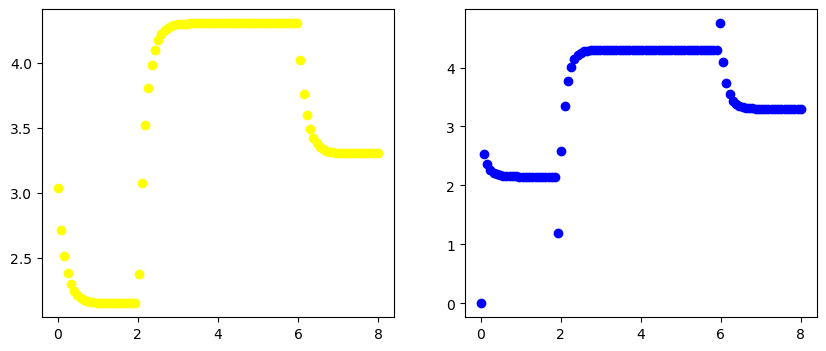

In [192]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(t, Vector_lambda_groudtruth[:, 0], label='groudtruth lambda_U', c='yellow')
# ax[1].scatter(t, NS_lambdas[:, 0], label='numerical lambda_U', c='blue')
ax[1].scatter(t, Backward_lambdas[:, 0], label='numerical lambda_U', c='blue')
# ax[1].scatter(t, X_fwd[:, 0], label='numerical lambda_U', c='blue')

In [49]:
X_fwd.shape

(100, 2)